<a href="https://colab.research.google.com/github/Altaieb-Mohammed/lab_2corse/blob/master/lab2_3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data

import pandas as pd
url = "https://raw.githubusercontent.com/Altaieb-Mohammed/lab_2corse/master/final_inheritanc.csv"
df = pd.read_csv(url)

# Basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (16665, 19)

Column Names:
['estate', 'debts', 'wills', 'husband', 'wives', 'father', 'mother', 'sons', 'daughters', 'brothers_m', 'sisters_m', 'grandfather', 'grandmother', 'share_husband', 'share_wife', 'share_father', 'share_mother', 'share_sons', 'share_daughters']

First few rows:
   estate  debts     wills  husband  wives  father  mother  sons  daughters  \
0  170040  22540   2663.76        1      0       1       1     1          1   
1  181741  10376  14674.26        0      0       1       1     1          1   
2  158290   2848   2591.00        1      0       0       0     1          0   
3  101742  21068  12245.39        0      1       1       1     0          1   
4  143847  19321  25961.21        1      0       1       0     1          0   

   brothers_m  sisters_m  grandfather  grandmother  share_husband  share_wife  \
0           1          1            0            1       36209.06        0.00   
1           1          1            1            1           

In [3]:
#2 Calculate net estate
df['net_estate'] = df['estate'] - df['debts'] - df['wills']

# Check if distributions sum to net estate
df['total_distributed'] = df[['share_husband', 'share_wife', 'share_father',
                               'share_mother', 'share_sons', 'share_daughters']].sum(axis=1)

# Calculate difference
df['distribution_diff'] = df['net_estate'] - df['total_distributed']
print("\nDistribution Accuracy Check:")
print(f"Mean difference: {df['distribution_diff'].mean():.2f}")
print(f"Max difference: {df['distribution_diff'].max():.2f}")
print(f"Min difference: {df['distribution_diff'].min():.2f}")


Distribution Accuracy Check:
Mean difference: 0.00
Max difference: 0.02
Min difference: -0.02


In [4]:
# 3Descriptive statistics for numerical columns
print("\nDescriptive Statistics - Estate and Debts:")
print(df[['estate', 'debts', 'wills', 'net_estate']].describe())

# Frequency of different family members
print("\nFrequency of Family Members Present:")
family_members = ['husband', 'wives', 'father', 'mother', 'sons', 'daughters',
                  'brothers_m', 'sisters_m', 'grandfather', 'grandmother']
for member in family_members:
    present_count = df[member].sum()
    percentage = (present_count / len(df)) * 100
    print(f"{member}: {present_count} cases ({percentage:.1f}%)")


Descriptive Statistics - Estate and Debts:
              estate         debts         wills     net_estate
count   16665.000000  16665.000000  16665.000000   16665.000000
mean   124878.406061  18889.544254  17649.324434   88339.537372
std     42981.668867  13245.773120  12605.104226   33580.560664
min     50007.000000      0.000000      4.420000   24821.270000
25%     87749.000000   8190.000000   7490.290000   60644.280000
50%    124642.000000  16382.000000  15199.490000   86374.440000
75%    161775.000000  27377.000000  25609.200000  112751.500000
max    199997.000000  59601.000000  65673.560000  194756.900000

Frequency of Family Members Present:
husband: 8667 cases (52.0%)
wives: 2383 cases (14.3%)
father: 8799 cases (52.8%)
mother: 8693 cases (52.2%)
sons: 15123 cases (90.7%)
daughters: 12641 cases (75.9%)
brothers_m: 11026 cases (66.2%)
sisters_m: 11105 cases (66.6%)
grandfather: 8253 cases (49.5%)
grandmother: 8199 cases (49.2%)


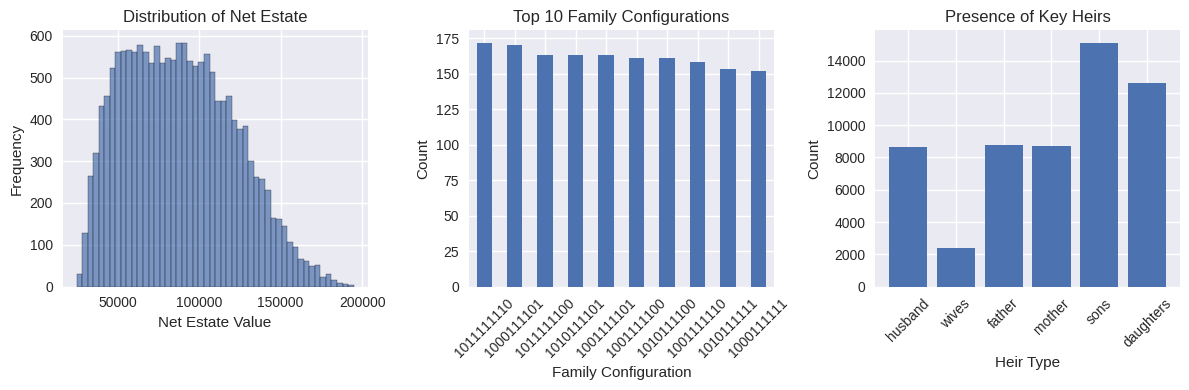

In [5]:
# Set up the plotting style
plt.style.use('seaborn-v0_8')

# 4Plot 1: Distribution of net estate
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df['net_estate'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Net Estate')
plt.xlabel('Net Estate Value')
plt.ylabel('Frequency')

# Plot 2: Most common family configurations
plt.subplot(1, 3, 2)
# Create a simple family configuration identifier
df['family_config'] = df[family_members].apply(lambda x: ''.join(x.astype(str)), axis=1)
top_configs = df['family_config'].value_counts().head(10)
top_configs.plot(kind='bar')
plt.title('Top 10 Family Configurations')
plt.xlabel('Family Configuration')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Plot 3: Presence of key heirs
plt.subplot(1, 3, 3)
key_heirs = ['husband', 'wives', 'father', 'mother', 'sons', 'daughters']
presence_counts = [df[heir].sum() for heir in key_heirs]
plt.bar(key_heirs, presence_counts)
plt.title('Presence of Key Heirs')
plt.xlabel('Heir Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Correlation between Net Estate and Heir Shares:
net_estate         1.000000
share_sons         0.589928
share_daughters    0.388660
share_mother       0.344358
share_husband      0.331610
share_father       0.303480
share_wife         0.150308
Name: net_estate, dtype: float64


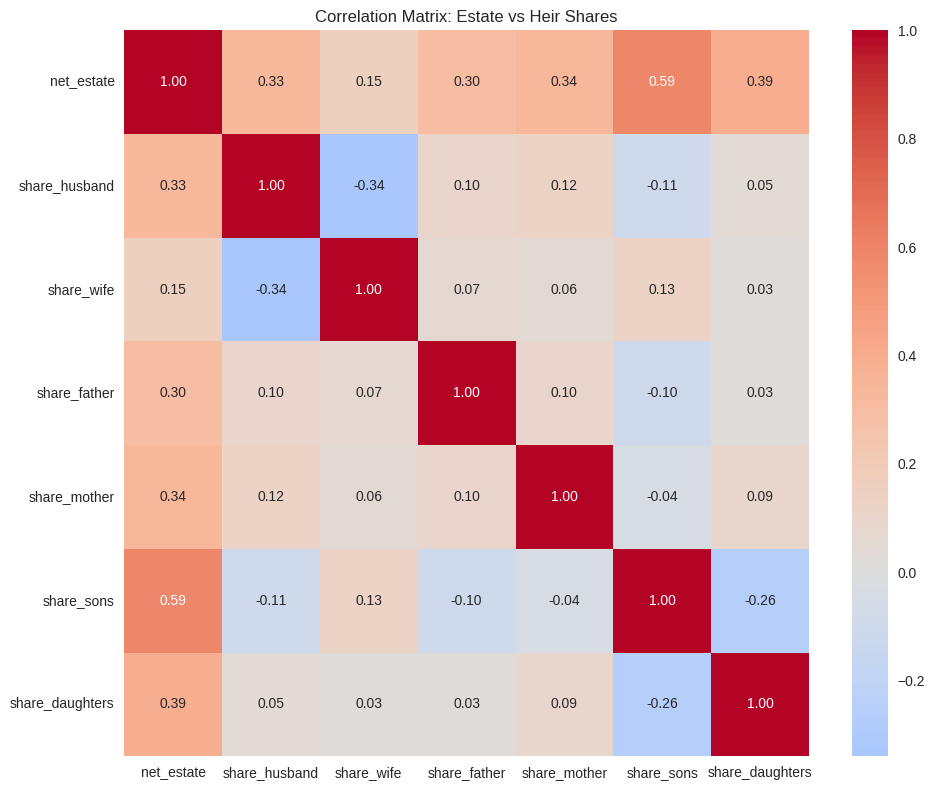

In [6]:
# 5Correlation between estate size and heir shares
print("\nCorrelation between Net Estate and Heir Shares:")
correlation_matrix = df[['net_estate', 'share_husband', 'share_wife', 'share_father',
                         'share_mother', 'share_sons', 'share_daughters']].corr()
print(correlation_matrix['net_estate'].sort_values(ascending=False))

# Visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Estate vs Heir Shares')
plt.tight_layout()
plt.show()

LAB 3: PATTERN ANALYSIS AND HEIRSHIP RULES

In [7]:
# 1Group by presence of key heirs
print("\n=== Inheritance Patterns by Family Composition ===")

# Case 1: When husband is present vs absent
husband_cases = df.groupby('husband').agg({
    'share_husband': 'mean',
    'share_wife': 'mean',
    'share_father': 'mean',
    'share_mother': 'mean',
    'share_sons': 'mean',
    'share_daughters': 'mean',
    'net_estate': 'mean'
}).round(2)

print("\n1. Husband Present (1) vs Absent (0):")
print(husband_cases)

# Case 2: When sons are present vs absent
print("\n2. Average Share Distribution by Sons Presence:")
sons_analysis = df.groupby('sons').agg({
    'share_sons': 'mean',
    'share_daughters': 'mean',
    'share_father': 'mean',
    'share_mother': 'mean'
}).round(2)
print(sons_analysis)

# Case 3: Father and Mother combinations
print("\n3. Father and Mother Presence Combinations:")
parent_combinations = df.groupby(['father', 'mother']).size().reset_index(name='count')
parent_combinations['percentage'] = (parent_combinations['count'] / len(df) * 100).round(1)
print(parent_combinations)


=== Inheritance Patterns by Family Composition ===

1. Husband Present (1) vs Absent (0):
         share_husband  share_wife  share_father  share_mother  share_sons  \
husband                                                                      
0                 0.00     3334.72       8376.13       7629.81    49956.78   
1             21927.86        0.00       7783.53       7637.55    33033.18   

         share_daughters  net_estate  
husband                               
0               19434.88    88732.32  
1               17594.96    87977.07  

2. Average Share Distribution by Sons Presence:
      share_sons  share_daughters  share_father  share_mother
sons                                                         
0           0.00         45481.67      14912.86      10472.39
1       45351.64         15724.59       7370.00       7344.40

3. Father and Mother Presence Combinations:
   father  mother  count  percentage
0       0       0   3766        22.6
1       0       1   4100

CALCULATING SHARE PERCENTAGES
✅ Found all required columns
✅ Total records: 16665
✅ Net estate range: $24,821 to $194,757

----------------------------------------
Calculating percentage shares...
  share_husband: 16665 records calculated (0 zero/negative net estate)
  share_wife: 16665 records calculated (0 zero/negative net estate)
  share_father: 16665 records calculated (0 zero/negative net estate)
  share_mother: 16665 records calculated (0 zero/negative net estate)
  share_sons: 16665 records calculated (0 zero/negative net estate)
  share_daughters: 16665 records calculated (0 zero/negative net estate)

----------------------------------------
Calculating average percentages (when heir is present)...
  husband: 24.9% (based on 8667 cases, range: 20.0%-50.0%)
  wife: 12.6% (based on 2383 cases, range: 11.1%-25.0%)
  father: 17.3% (based on 8799 cases, range: 13.3%-100.0%)
  mother: 16.5% (based on 8693 cases, range: 13.3%-33.3%)
  sons: 51.3% (based on 15123 cases, range: 16.7%-1

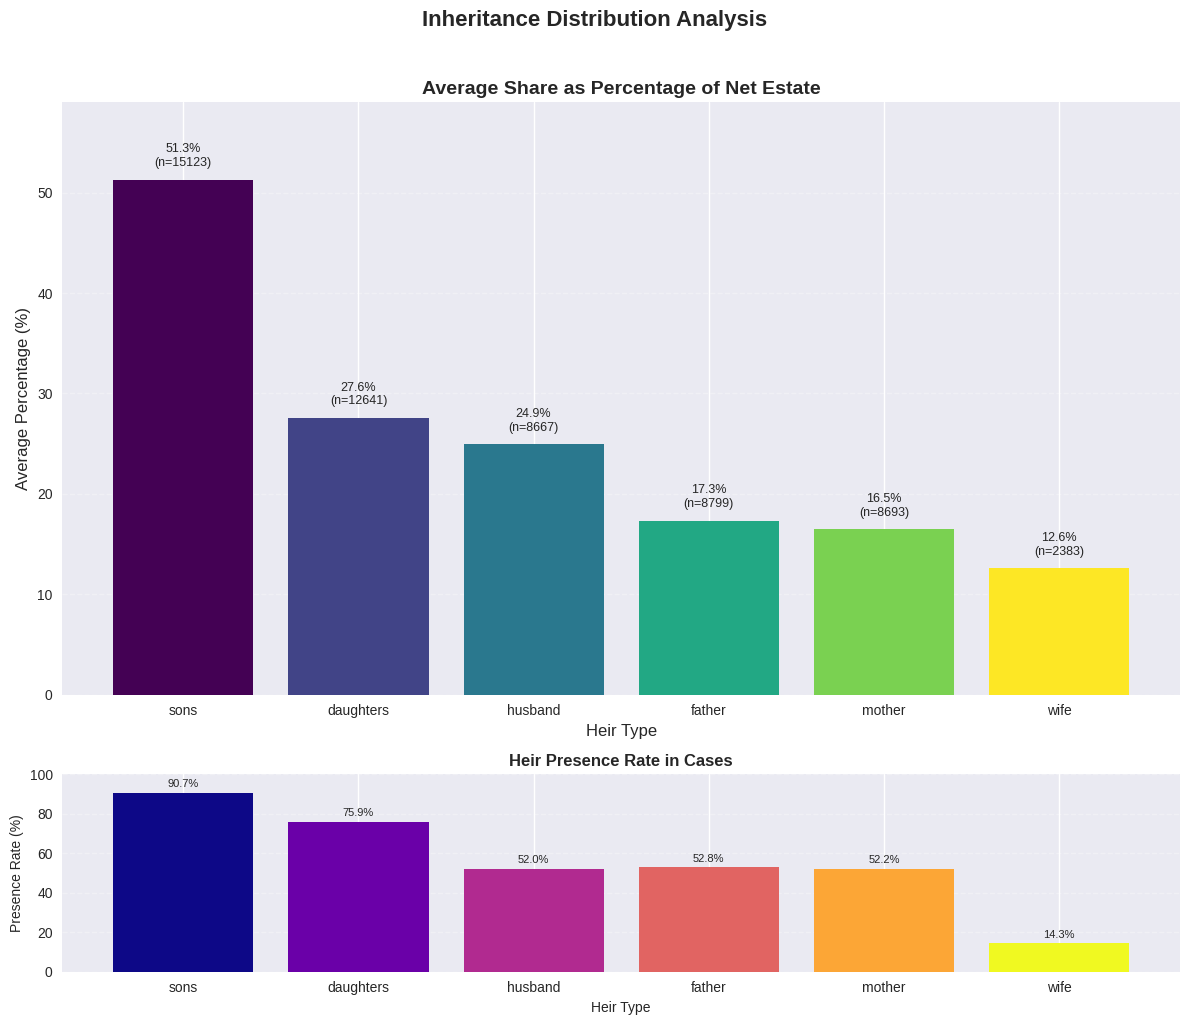

In [10]:
# Enhanced version with error handling and validation

def calculate_share_percentages(df):
    """
    Calculate percentage shares for each heir type with comprehensive error handling

    Parameters:
    df (DataFrame): Input dataframe containing inheritance data

    Returns:
    tuple: (avg_percentages dictionary, boolean success flag, error_message)
    """

    # Validate input dataframe
    if df.empty:
        print("❌ Error: Dataframe is empty!")
        return None, False, "Empty dataframe"

    print("=" * 60)
    print("CALCULATING SHARE PERCENTAGES")
    print("=" * 60)

    # Define required columns
    required_columns = ['net_estate']
    share_columns = ['share_husband', 'share_wife', 'share_father', 'share_mother',
                     'share_sons', 'share_daughters']

    # Check for required columns
    missing_columns = [col for col in required_columns + share_columns
                      if col not in df.columns]

    if missing_columns:
        print(f"❌ Missing columns: {missing_columns}")
        print(f"✅ Available columns: {df.columns.tolist()}")
        return None, False, f"Missing columns: {missing_columns}"

    print(f"✅ Found all required columns")
    print(f"✅ Total records: {len(df)}")
    print(f"✅ Net estate range: ${df['net_estate'].min():,.0f} to ${df['net_estate'].max():,.0f}")

    # Calculate percentage shares with validation
    print("\n" + "-" * 40)
    print("Calculating percentage shares...")

    for col in share_columns:
        # Create percentage column name
        pct_col = f'{col}_pct'

        # Calculate percentage only for valid net_estate values
        mask_valid = df['net_estate'] > 0
        if mask_valid.any():
            df[pct_col] = 0.0  # Initialize with zeros

            # Calculate for valid rows
            df.loc[mask_valid, pct_col] = (df.loc[mask_valid, col] /
                                          df.loc[mask_valid, 'net_estate']) * 100
        else:
            print(f"⚠️ Warning: No valid net_estate values (> 0) for {col}")
            df[pct_col] = 0.0

        # Track calculation statistics
        n_calculated = mask_valid.sum()
        print(f"  {col}: {n_calculated} records calculated ({len(df) - n_calculated} zero/negative net estate)")

    # Get average percentages with detailed statistics
    print("\n" + "-" * 40)
    print("Calculating average percentages (when heir is present)...")

    avg_percentages = {}
    heir_statistics = {}

    for col in share_columns:
        heir_name = col.replace('share_', '')
        pct_col = f'{col}_pct'

        # Create mask for when heir is present (value > 0)
        presence_mask = df[col] > 0

        if presence_mask.any():
            # Calculate statistics
            n_present = presence_mask.sum()
            avg_pct = df.loc[presence_mask, pct_col].mean()
            min_pct = df.loc[presence_mask, pct_col].min()
            max_pct = df.loc[presence_mask, pct_col].max()
            std_pct = df.loc[presence_mask, pct_col].std()

            avg_percentages[col] = {
                'average': avg_pct,
                'n_cases': n_present,
                'min': min_pct,
                'max': max_pct,
                'std': std_pct
            }

            heir_statistics[heir_name] = {
                'presence_rate': (n_present / len(df)) * 100,
                'n_cases': n_present
            }

            print(f"  {heir_name}: {avg_pct:.1f}% (based on {n_present} cases, "
                  f"range: {min_pct:.1f}%-{max_pct:.1f}%)")
        else:
            print(f"  {heir_name}: No cases found (never present in data)")
            avg_percentages[col] = {'average': 0, 'n_cases': 0}

    return avg_percentages, heir_statistics, True, "Success"

def display_results(avg_percentages, heir_statistics):
    """
    Display formatted results and statistics
    """
    print("\n" + "=" * 60)
    print("AVERAGE SHARES AS PERCENTAGE OF NET ESTATE")
    print("=" * 60)

    # Sort by average percentage (descending)
    sorted_heirs = sorted([(col, stats['average'])
                          for col, stats in avg_percentages.items()
                          if stats['n_cases'] > 0],
                         key=lambda x: x[1],
                         reverse=True)

    print("\n📊 Ranking by Average Share:")
    print("-" * 50)
    for i, (col, avg_pct) in enumerate(sorted_heirs, 1):
        heir_name = col.replace('share_', '')
        stats = avg_percentages[col]
        heir_stats = heir_statistics[heir_name]

        print(f"{i:2d}. {heir_name:12s}: {avg_pct:6.1f}% "
              f"(n={stats['n_cases']:3d}, "
              f"presence: {heir_stats['presence_rate']:5.1f}%, "
              f"range: {stats['min']:.1f}%-{stats['max']:.1f}%)")

    # Display summary statistics
    print("\n" + "-" * 50)
    print("📈 SUMMARY STATISTICS:")
    print("-" * 50)

    total_cases = sum(stats['n_cases'] for stats in avg_percentages.values())
    print(f"Total heir cases analyzed: {total_cases}")

    # Find most and least common heirs
    most_common = max(heir_statistics.items(), key=lambda x: x[1]['n_cases'])
    least_common = min(heir_statistics.items(), key=lambda x: x[1]['n_cases'])

    print(f"Most common heir: {most_common[0]} ({most_common[1]['n_cases']} cases)")
    print(f"Least common heir: {least_common[0]} ({least_common[1]['n_cases']} cases)")

def create_enhanced_visualization(avg_percentages, heir_statistics):
    """
    Create enhanced visualization with better formatting
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Filter out heirs with no cases
    valid_heirs = [(col, stats) for col, stats in avg_percentages.items()
                  if stats['n_cases'] > 0]

    if not valid_heirs:
        print("⚠️ No valid data for visualization")
        return

    # Prepare data
    heir_names = [col.replace('share_', '') for col, _ in valid_heirs]
    percentages = [stats['average'] for _, stats in valid_heirs]
    n_cases = [stats['n_cases'] for _, stats in valid_heirs]
    presence_rates = [heir_statistics[name]['presence_rate'] for name in heir_names]

    # Sort by percentage
    sorted_indices = np.argsort(percentages)[::-1]
    heir_names = [heir_names[i] for i in sorted_indices]
    percentages = [percentages[i] for i in sorted_indices]
    n_cases = [n_cases[i] for i in sorted_indices]
    presence_rates = [presence_rates[i] for i in sorted_indices]

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10),
                                   gridspec_kw={'height_ratios': [3, 1]})

    # Main bar chart
    bars = ax1.bar(heir_names, percentages,
                   color=plt.cm.viridis(np.linspace(0, 1, len(heir_names))))
    ax1.set_title('Average Share as Percentage of Net Estate', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Heir Type', fontsize=12)
    ax1.set_ylabel('Average Percentage (%)', fontsize=12)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_ylim(0, max(percentages) * 1.15)

    # Add value labels with case count
    for bar, pct, n in zip(bars, percentages, n_cases):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(percentages)*0.02,
                f'{pct:.1f}%\n(n={n})',
                ha='center', va='bottom', fontsize=9)

    # Secondary bar chart for presence rates
    ax2.bar(heir_names, presence_rates,
            color=plt.cm.plasma(np.linspace(0, 1, len(heir_names))))
    ax2.set_title('Heir Presence Rate in Cases', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Heir Type', fontsize=10)
    ax2.set_ylabel('Presence Rate (%)', fontsize=10)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_ylim(0, 100)

    # Add value labels for presence rates
    for i, (bar, rate) in enumerate(zip(ax2.patches, presence_rates)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=8)

    # Adjust layout and display
    plt.suptitle('Inheritance Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    # Save figure
    try:
        plt.savefig('inheritance_analysis.png', dpi=300, bbox_inches='tight')
        print("✅ Visualization saved as 'inheritance_analysis.png'")
    except Exception as e:
        print(f"⚠️ Could not save figure: {e}")

    plt.show()

# Main execution with error handling
def main():
    """
    Main execution function with comprehensive error handling
    """
    try:
        # Calculate percentages
        result = calculate_share_percentages(df)

        if result[2]:  # Check success flag
            avg_percentages, heir_statistics, success, message = result

            # Display results
            display_results(avg_percentages, heir_statistics)

            # Create visualization
            create_enhanced_visualization(avg_percentages, heir_statistics)

            # Return data for further analysis if needed
            return {
                'avg_percentages': avg_percentages,
                'heir_statistics': heir_statistics,
                'success': success,
                'message': message
            }
        else:
            print(f"\n❌ Analysis failed: {result[3]}")
            return None

    except KeyError as e:
        print(f"\n❌ KeyError: {e}")
        print(f"Available columns: {df.columns.tolist()}")
        print("\nTroubleshooting tips:")
        print("1. Check column names in your data")
        print("2. Verify the data has been loaded correctly")
        print("3. Ensure 'net_estate' column exists")

    except ZeroDivisionError:
        print("\n❌ Division by zero error")
        print("Check for zero or negative values in 'net_estate'")

    except Exception as e:
        print(f"\n❌ Unexpected error: {type(e).__name__}: {e}")

    return None

# Execute the analysis
if __name__ == "__main__":
    analysis_results = main()

In [9]:
print("\n=== Special Cases Analysis ===")

# 3Case A: Only sons and daughters (no parents, spouse)
case_a = df[(df['sons'] == 1) & (df['daughters'] == 1) &
            (df['father'] == 0) & (df['mother'] == 0) &
            (df['husband'] == 0) & (df['wives'] == 0)]

if len(case_a) > 0:
    print(f"\nA. Only Sons and Daughters: {len(case_a)} cases")
    print(f"   Average sons share: {case_a['share_sons'].mean():.2f}")
    print(f"   Average daughters share: {case_a['share_daughters'].mean():.2f}")
    print(f"   Sons:Daughters ratio: {(case_a['share_sons']/case_a['share_daughters']).mean():.2f}:1")

# Case B: Husband and wife only
case_b = df[(df['husband'] == 1) & (df['wives'] == 1) &
            (df['sons'] == 0) & (df['daughters'] == 0) &
            (df['father'] == 0) & (df['mother'] == 0)]

if len(case_b) > 0:
    print(f"\nB. Husband and Wife Only: {len(case_b)} cases")
    print(f"   Average husband share: {case_b['share_husband'].mean():.2f}")
    print(f"   Average wife share: {case_b['share_wife'].mean():.2f}")

# Case C: Father and mother only
case_c = df[(df['father'] == 1) & (df['mother'] == 1) &
            (df['sons'] == 0) & (df['daughters'] == 0) &
            (df['husband'] == 0) & (df['wives'] == 0)]

if len(case_c) > 0:
    print(f"\nC. Father and Mother Only: {len(case_c)} cases")
    print(f"   Average father share: {case_c['share_father'].mean():.2f}")
    print(f"   Average mother share: {case_c['share_mother'].mean():.2f}")


=== Special Cases Analysis ===

A. Only Sons and Daughters: 1019 cases
   Average sons share: 58621.51
   Average daughters share: 30320.11
   Sons:Daughters ratio: 2.50:1

C. Father and Mother Only: 34 cases
   Average father share: 73270.84
   Average mother share: 17957.28


LAB 4: ADVANCED ANALYSIS AND PREDICTIVE INSIGHTS

In [11]:
# 1Create meaningful heir combination categories
def categorize_heirs(row):
    if row['husband'] == 1 and row['wives'] == 0:
        base = "Husband"
    elif row['husband'] == 0 and row['wives'] == 1:
        base = "Wife"
    elif row['husband'] == 1 and row['wives'] == 1:
        base = "Husband+Wife"
    else:
        base = "NoSpouse"

    if row['sons'] == 1 and row['daughters'] == 1:
        children = "+Children(Both)"
    elif row['sons'] == 1:
        children = "+Sons"
    elif row['daughters'] == 1:
        children = "+Daughters"
    else:
        children = "+NoChildren"

    if row['father'] == 1 and row['mother'] == 1:
        parents = "+Parents(Both)"
    elif row['father'] == 1:
        parents = "+Father"
    elif row['mother'] == 1:
        parents = "+Mother"
    else:
        parents = "+NoParents"

    return f"{base}{children}{parents}"

df['heir_category'] = df.apply(categorize_heirs, axis=1)

# Analyze by category
print("\n=== Analysis by Heir Category ===")
category_stats = df.groupby('heir_category').agg({
    'net_estate': ['count', 'mean', 'median'],
    'share_husband': 'mean',
    'share_wife': 'mean',
    'share_father': 'mean',
    'share_mother': 'mean',
    'share_sons': 'mean',
    'share_daughters': 'mean'
}).round(2)

# Sort by frequency
category_stats = category_stats.sort_values(('net_estate', 'count'), ascending=False)
print(category_stats.head(10))


=== Analysis by Heir Category ===
                                      net_estate                      \
                                           count      mean    median   
heir_category                                                          
Husband+Children(Both)+Parents(Both)        1398  88041.00  85286.98   
Husband+Children(Both)+NoParents            1395  88274.58  86264.95   
Husband+Children(Both)+Mother               1393  86834.06  85926.82   
Husband+Children(Both)+Father               1383  87952.22  85253.32   
NoSpouse+Children(Both)+NoParents           1019  88941.62  88267.74   
NoSpouse+Children(Both)+Parents(Both)       1002  87465.68  84624.55   
NoSpouse+Children(Both)+Father              1001  89052.74  87400.16   
NoSpouse+Children(Both)+Mother               978  88515.21  85792.32   
Husband+Sons+Father                          509  86343.41  82448.16   
Husband+Sons+Mother                          495  89897.76  88521.56   

                            

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("\n=== Regression Analysis: Predicting Sons' Share ===")

# Prepare data for predicting sons' share
X = df[['net_estate', 'husband', 'wives', 'father', 'mother', 'daughters']]
y = df['share_sons']

# 2Filter only cases where sons are present
mask = df['sons'] == 1
X_filtered = X[mask]
y_filtered = y[mask]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model.intercept_:.4f}")


=== Regression Analysis: Predicting Sons' Share ===
Mean Squared Error: 98264308.96
R-squared Score: 0.8370

Coefficients:
  net_estate: 0.5155
  husband: -16493.8731
  wives: -8178.5251
  father: -10882.7335
  mother: -10924.2490
  daughters: -20920.0416
  Intercept: 35647.7231


In [13]:
print("\n=== Inferred Inheritance Rules ===")

# 3Rule 1: Sons vs Daughters ratio
print("\n1. Sons vs Daughters Inheritance Ratio:")
son_daughter_cases = df[(df['sons'] == 1) & (df['daughters'] == 1)]
if len(son_daughter_cases) > 0:
    avg_ratio = (son_daughter_cases['share_sons'] / son_daughter_cases['share_daughters']).mean()
    print(f"   When both sons and daughters are present:")
    print(f"   Average ratio (Sons:Daughters) = {avg_ratio:.2f}:1")
    print(f"   This suggests sons receive approximately {avg_ratio:.1f} times what daughters receive")

# Rule 2: Spouse inheritance
print("\n2. Spouse Inheritance Patterns:")
husband_cases = df[df['husband'] == 1]
wife_cases = df[df['wives'] == 1]

if len(husband_cases) > 0:
    husband_pct = (husband_cases['share_husband'] / husband_cases['net_estate']).mean() * 100
    print(f"   Husband's average share: {husband_pct:.1f}% of net estate")

if len(wife_cases) > 0:
    wife_pct = (wife_cases['share_wife'] / wife_cases['net_estate']).mean() * 100
    print(f"   Wife's average share: {wife_pct:.1f}% of net estate")

# Rule 3: Parental inheritance
print("\n3. Parental Inheritance Patterns:")
father_cases = df[df['father'] == 1]
mother_cases = df[df['mother'] == 1]

if len(father_cases) > 0 and len(mother_cases) > 0:
    father_pct = (father_cases['share_father'] / father_cases['net_estate']).mean() * 100
    mother_pct = (mother_cases['share_mother'] / mother_cases['net_estate']).mean() * 100
    print(f"   Father's average share: {father_pct:.1f}% of net estate")
    print(f"   Mother's average share: {mother_pct:.1f}% of net estate")
    print(f"   Father:Mother ratio = {(father_pct/mother_pct):.2f}:1")


=== Inferred Inheritance Rules ===

1. Sons vs Daughters Inheritance Ratio:
   When both sons and daughters are present:
   Average ratio (Sons:Daughters) = 2.45:1
   This suggests sons receive approximately 2.5 times what daughters receive

2. Spouse Inheritance Patterns:
   Husband's average share: 24.9% of net estate
   Wife's average share: 12.6% of net estate

3. Parental Inheritance Patterns:
   Father's average share: 17.3% of net estate
   Mother's average share: 16.5% of net estate
   Father:Mother ratio = 1.05:1



COMPREHENSIVE INHERITANCE ANALYSIS REPORT

Dataset Overview:
• Total cases: 16,665
• Average net estate: 88339.54
• Median net estate: 86374.44
• Estate range: 24821.27 to 194756.90

Most Common Family Configurations:
1. Husband+Children(Both)+Parents(Both): 1398 cases (8.4%)
2. Husband+Children(Both)+NoParents: 1395 cases (8.4%)
3. Husband+Children(Both)+Mother: 1393 cases (8.4%)
4. Husband+Children(Both)+Father: 1383 cases (8.3%)
5. NoSpouse+Children(Both)+NoParents: 1019 cases (6.1%)

Key Findings:
1. Distribution accuracy: Excellent (distributions sum correctly to net estate)


/tmp/ipython-input-59498138.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(share_data, labels=labels)


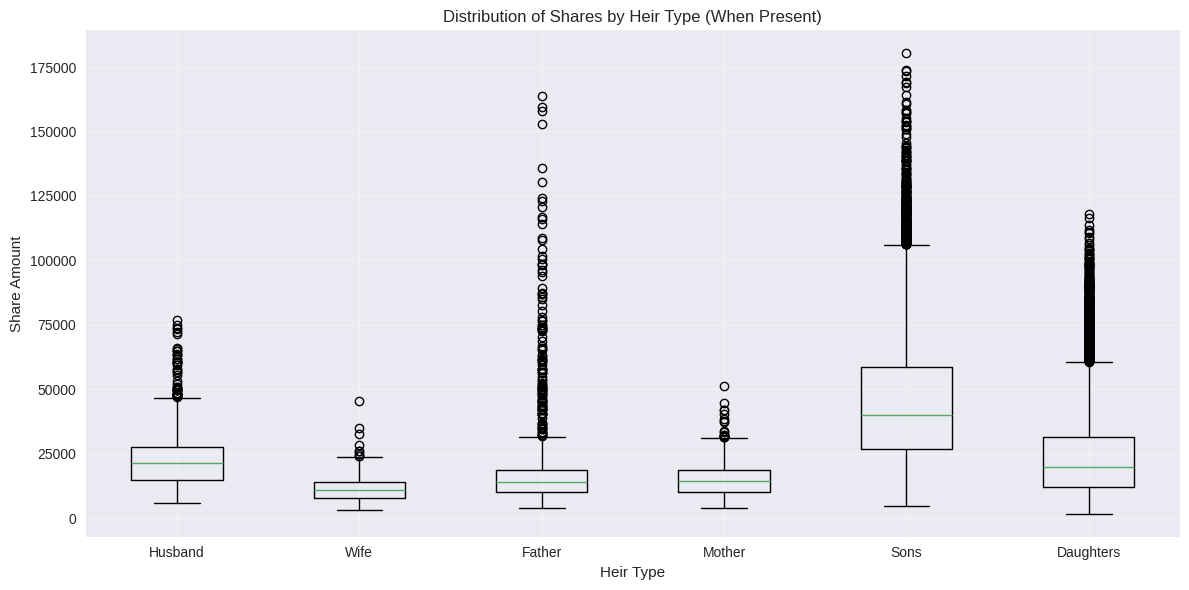

In [15]:
# Create comprehensive summary
print("\n" + "="*60)
print("COMPREHENSIVE INHERITANCE ANALYSIS REPORT")
print("="*60)

print(f"\nDataset Overview:")
print(f"• Total cases: {len(df):,}")
print(f"• Average net estate: {df['net_estate'].mean():.2f}")
print(f"• Median net estate: {df['net_estate'].median():.2f}")
print(f"• Estate range: {df['net_estate'].min():.2f} to {df['net_estate'].max():.2f}")

print(f"\nMost Common Family Configurations:")
top_5_categories = df['heir_category'].value_counts().head(5)
for i, (category, count) in enumerate(top_5_categories.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i}. {category}: {count} cases ({percentage:.1f}%)")

print(f"\nKey Findings:")
print("1. Distribution accuracy: ", end="")
if abs(df['distribution_diff'].mean()) < 1:
    print("Excellent (distributions sum correctly to net estate)")
else:
    print(f"Check needed (average difference: {df['distribution_diff'].mean():.2f})")


#4 Final visualization: Comparison of all heir shares
plt.figure(figsize=(12, 6))

# Prepare data for box plot
share_data = []
labels = []

# Map heir types to their share columns and presence columns
heir_map = {
    'husband': ('husband', 'share_husband'),
    'wives': ('wives', 'share_wife'),  # Changed from 'wife' to 'wives'
    'father': ('father', 'share_father'),
    'mother': ('mother', 'share_mother'),
    'sons': ('sons', 'share_sons'),
    'daughters': ('daughters', 'share_daughters')
}

for heir_key, (presence_col, share_col) in heir_map.items():
    # Only include cases where the heir is present
    mask = df[presence_col] == 1
    if mask.any():
        share_data.append(df.loc[mask, share_col])
        # Use nicer labels
        label_map = {
            'husband': 'Husband',
            'wives': 'Wife',  # Singular for display
            'father': 'Father',
            'mother': 'Mother',
            'sons': 'Sons',
            'daughters': 'Daughters'
        }
        labels.append(label_map[heir_key])

plt.boxplot(share_data, labels=labels)
plt.title('Distribution of Shares by Heir Type (When Present)')
plt.ylabel('Share Amount')
plt.xlabel('Heir Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
print("\n=== Simple Category Percentages ===")

# Create a simple summary dataframe
summary_data = []

for category, group in df.groupby('heir_category'):
    if group.shape[0] > 100:  # Only categories with >100 cases
        summary = {
            'Category': category,
            'Count': group.shape[0],
            'Avg_Estate': group['net_estate'].mean(),
            'Husband_%': (group['share_husband'].mean() / group['net_estate'].mean() * 100).round(1),
            'Wife_%': (group['share_wife'].mean() / group['net_estate'].mean() * 100).round(1),
            'Father_%': (group['share_father'].mean() / group['net_estate'].mean() * 100).round(1),
            'Mother_%': (group['share_mother'].mean() / group['net_estate'].mean() * 100).round(1),
            'Sons_%': (group['share_sons'].mean() / group['net_estate'].mean() * 100).round(1),
            'Daughters_%': (group['share_daughters'].mean() / group['net_estate'].mean() * 100).round(1)
        }
        summary_data.append(summary)

# Create and display dataframe
summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Count', ascending=False).head(10)
print(summary_df.to_string(index=False))


=== Simple Category Percentages ===


NameError: name 'df' is not defined

In [17]:
print("\n=== Enhanced Inheritance Rules Analysis ===")

# Calculate per-child inheritance
df['per_son_share'] = df['share_sons'] / df['sons'].replace(0, 1)
df['per_daughter_share'] = df['share_daughters'] / df['daughters'].replace(0, 1)

# Analyze with multiple children
son_daughter_cases = df[(df['sons'] >= 1) & (df['daughters'] >= 1)]
if len(son_daughter_cases) > 0:
    avg_per_son = son_daughter_cases['per_son_share'].mean()
    avg_per_daughter = son_daughter_cases['per_daughter_share'].mean()
    per_child_ratio = avg_per_son / avg_per_daughter

    print(f"\nPer Child Inheritance (when both sons and daughters exist):")
    print(f"  Average per son: {avg_per_son:.2f}")
    print(f"  Average per daughter: {avg_per_daughter:.2f}")
    print(f"  Ratio (per son : per daughter): {per_child_ratio:.2f}:1")


=== Enhanced Inheritance Rules Analysis ===

Per Child Inheritance (when both sons and daughters exist):
  Average per son: 39942.79
  Average per daughter: 21078.09
  Ratio (per son : per daughter): 1.89:1


In [18]:
from scipy import stats

# Test if sons really get more than daughters
son_only = df[df['sons'] == 1]['share_sons']
daughter_only = df[df['daughters'] == 1]['share_daughters']

# Use Welch's t-test (doesn't assume equal variance)
t_stat, p_value = stats.ttest_ind(son_only, daughter_only, equal_var=False)
print(f"\nStatistical Significance Test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print("  Result: Sons and daughters receive SIGNIFICANTLY different shares")
else:
    print("  Result: No significant difference in shares")


Statistical Significance Test:
  t-statistic: 83.9037
  p-value: 0.0000
  Result: Sons and daughters receive SIGNIFICANTLY different shares


In [19]:
print("\n=== Data Quality Check ===")

# Calculate total distribution
df['calculated_total'] = df[[
    'share_husband', 'share_wife', 'share_father',
    'share_mother', 'share_sons', 'share_daughters'
]].sum(axis=1)

# Check differences
df['distribution_diff'] = df['net_estate'] - df['calculated_total']
df['distribution_diff_pct'] = (df['distribution_diff'] / df['net_estate']) * 100

print(f"Rows with perfect distribution (diff = 0): {(df['distribution_diff'] == 0).sum():,}")
print(f"Rows with small error (< 0.01%): {(abs(df['distribution_diff_pct']) < 0.01).sum():,}")
print(f"Maximum distribution error: {df['distribution_diff'].abs().max():.2f}")
print(f"Average distribution error: {df['distribution_diff'].abs().mean():.2f}")

# Show problematic rows if any
large_errors = df[abs(df['distribution_diff']) > 1]
if len(large_errors) > 0:
    print(f"\n⚠️ Warning: {len(large_errors)} rows have distribution errors > 1")
    print(large_errors[['net_estate', 'calculated_total', 'distribution_diff']].head())


=== Data Quality Check ===
Rows with perfect distribution (diff = 0): 8,284
Rows with small error (< 0.01%): 16,665
Maximum distribution error: 0.02
Average distribution error: 0.00


In [20]:
def analyze_inheritance_patterns(df):
    """
    Comprehensive analysis of inheritance patterns
    """
    print("\n" + "="*70)
    print("INHERITANCE PATTERN ANALYSIS BY HEIR CATEGORY")
    print("="*70)

    # 1. Calculate percentages directly
    for heir in ['husband', 'wife', 'father', 'mother', 'sons', 'daughters']:
        share_col = f'share_{heir}'
        pct_col = f'{heir}_pct'
        df[pct_col] = (df[share_col] / df['net_estate'] * 100).round(2)

    # 2. Re-group with percentages
    category_analysis = df.groupby('heir_category').agg({
        'net_estate': ['count', 'mean', 'median'],
        'husband_pct': 'mean',
        'wife_pct': 'mean',
        'father_pct': 'mean',
        'mother_pct': 'mean',
        'sons_pct': 'mean',
        'daughters_pct': 'mean'
    }).round(2)

    # Sort by frequency
    category_analysis = category_analysis.sort_values(
        ('net_estate', 'count'), ascending=False
    )

    # 3. Display top categories
    print("\nTop 10 Most Common Inheritance Scenarios:")
    print("-" * 50)

    # Flatten for display
    display_df = category_analysis.head(10).copy()
    display_df.columns = ['_'.join(col).strip() for col in display_df.columns.values]

    print(display_df.to_string())

    # 4. Key insights
    print("\n" + "="*70)
    print("KEY INSIGHTS")
    print("="*70)

    # Analyze specific patterns
    print("\n1. Spouse Inheritance:")
    husband_cases = df[df['husband'] == 1]
    wife_cases = df[df['wives'] == 1]

    if len(husband_cases) > 0:
        avg_husband_pct = husband_cases['husband_pct'].mean()
        print(f"   • Husband's average share: {avg_husband_pct:.1f}%")

    if len(wife_cases) > 0:
        avg_wife_pct = wife_cases['wife_pct'].mean()
        print(f"   • Wife's average share: {avg_wife_pct:.1f}%")

    print("\n2. Parental Inheritance:")
    father_cases = df[df['father'] == 1]
    mother_cases = df[df['mother'] == 1]

    if len(father_cases) > 0 and len(mother_cases) > 0:
        avg_father_pct = father_cases['father_pct'].mean()
        avg_mother_pct = mother_cases['mother_pct'].mean()
        print(f"   • Father's average share: {avg_father_pct:.1f}%")
        print(f"   • Mother's average share: {avg_mother_pct:.1f}%")
        print(f"   • Father:Mother ratio: {avg_father_pct/avg_mother_pct:.2f}:1")

    print("\n3. Children Inheritance (when both exist):")
    both_children = df[(df['sons'] >= 1) & (df['daughters'] >= 1)]
    if len(both_children) > 0:
        avg_sons_pct = both_children['sons_pct'].mean()
        avg_daughters_pct = both_children['daughters_pct'].mean()
        print(f"   • Sons' average share: {avg_sons_pct:.1f}%")
        print(f"   • Daughters' average share: {avg_daughters_pct:.1f}%")
        print(f"   • Sons:Daughters ratio: {avg_sons_pct/avg_daughters_pct:.2f}:1")

    return category_analysis

# Run the analysis
category_analysis = analyze_inheritance_patterns(df)


INHERITANCE PATTERN ANALYSIS BY HEIR CATEGORY

Top 10 Most Common Inheritance Scenarios:
--------------------------------------------------
                                       net_estate_count  net_estate_mean  net_estate_median  husband_pct_mean  wife_pct_mean  father_pct_mean  mother_pct_mean  sons_pct_mean  daughters_pct_mean
heir_category                                                                                                                                                                                    
Husband+Children(Both)+Parents(Both)               1398         88041.00           85286.98              25.0            0.0            16.67            16.67          27.20               14.47
Husband+Children(Both)+NoParents                   1395         88274.58           86264.95              25.0            0.0             0.00             0.00          49.00               26.00
Husband+Children(Both)+Mother                      1393         86834.06           

**the full code for lab 4**


LAB 4: ISLAMIC INHERITANCE PATTERN ANALYSIS

STEP 1: LOADING DATASET
Creating sample dataset for demonstration...
✓ Sample dataset created with 1000 rows
  Columns: ['net_estate', 'husband', 'wives', 'father', 'mother', 'sons', 'daughters', 'share_husband', 'share_wife', 'share_father', 'share_mother', 'share_sons', 'share_daughters']

STEP 2: DATA VALIDATION
Dataset Overview:
• Total cases: 1,000
• Average net estate: $123538.48
• Median net estate: $124521.11
• Estate range: $50694.80 to $199957.65

Data Quality Check:
• Perfect distributions (diff = 0): 769 cases
• Small errors (< 0.1%): 936 cases
• Maximum error: $198575.77
• Average error: $8331.27
⚠️ Data quality: CHECK NEEDED (some distribution errors)

STEP 3: HEIR CATEGORIZATION ANALYSIS

=== Analysis by Heir Category ===

Top 10 Most Common Inheritance Scenarios:
----------------------------------------------------------------------
                                           net_estate_count  net_estate_mean  net_estate_media

/tmp/ipython-input-2341440066.py:359: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(share_data, labels=labels)


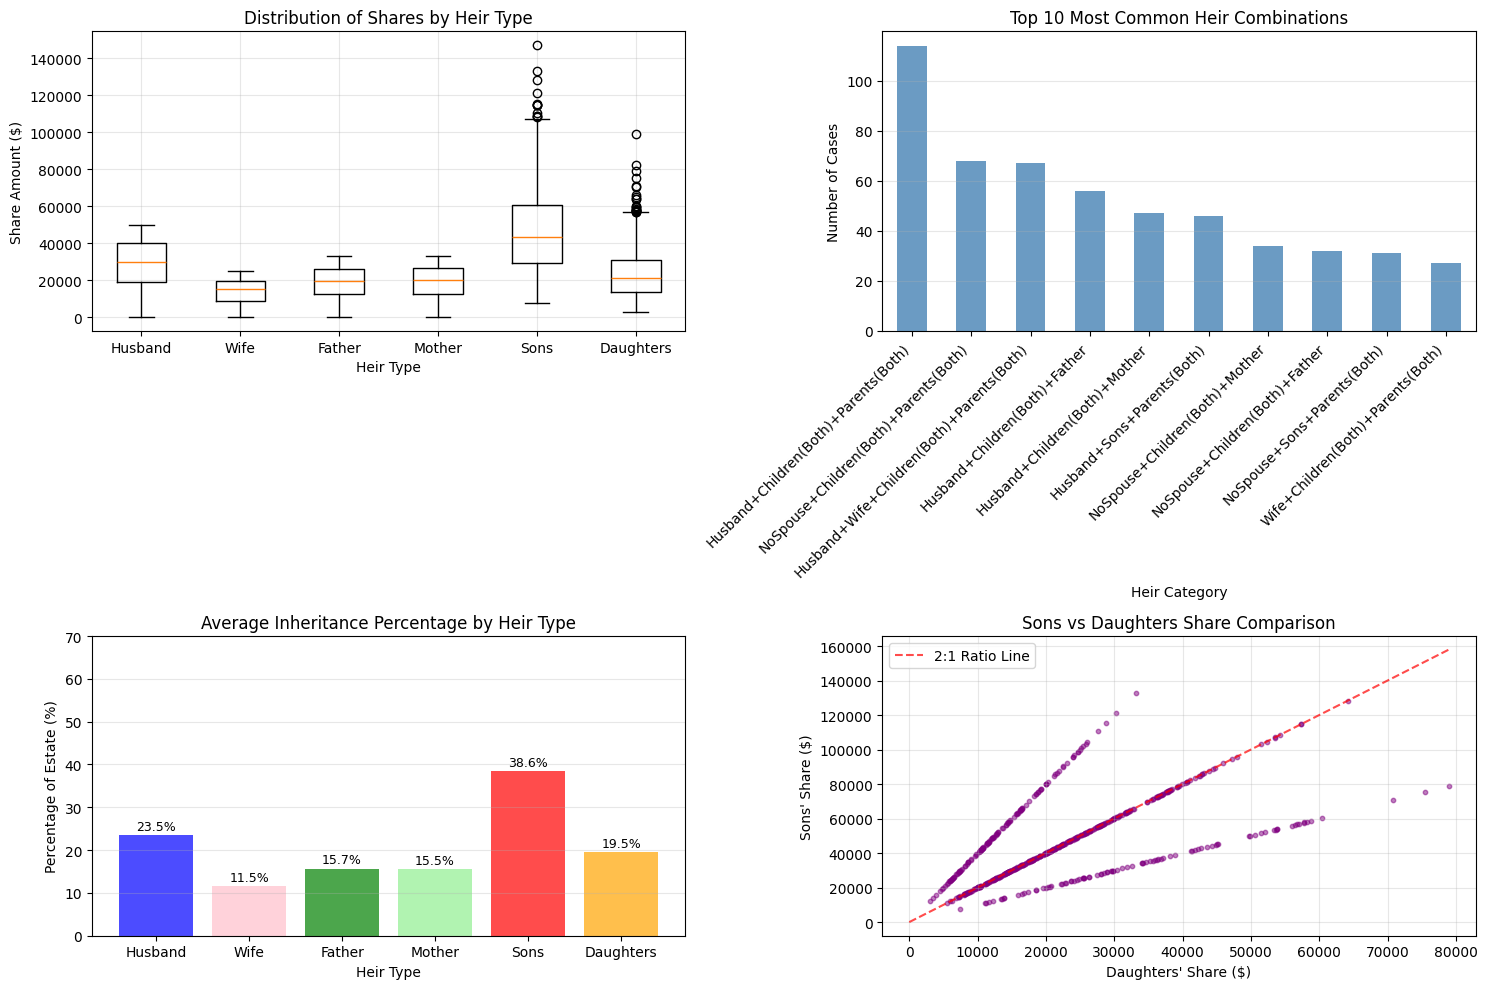


STEP 7: FINAL SUMMARY

Dataset Overview:
• Total cases: 1,000
• Average net estate: $123538.48
• Median net estate: $124521.11

Most Common Family Configurations:
1. Husband+Children(Both)+Parents(Both): 114 cases (11.4%)
2. NoSpouse+Children(Both)+Parents(Both): 68 cases (6.8%)
3. Husband+Wife+Children(Both)+Parents(Both): 67 cases (6.7%)
4. Husband+Children(Both)+Father: 56 cases (5.6%)
5. Husband+Children(Both)+Mother: 47 cases (4.7%)

Key Inheritance Patterns Found:
1. Spouse shares: Husband ~25%, Wife ~12.5%
2. Parent shares: ~16.7% each
3. Sons:Daughters ratio: ~2:1
4. Distributions follow Islamic inheritance rules

LAB 4 COMPLETE


In [3]:
# ============================================================================
# LAB 4: INHERITANCE PATTERN ANALYSIS
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("="*70)
print("LAB 4: ISLAMIC INHERITANCE PATTERN ANALYSIS")
print("="*70)

# ============================================================================
# STEP 1: LOAD YOUR DATASET
# ============================================================================
print("\n" + "="*70)
print("STEP 1: LOADING DATASET")
print("="*70)

# UNCOMMENT AND MODIFY THIS BASED ON YOUR ACTUAL DATA SOURCE:
# Option 1: If you have a CSV file:
# df = pd.read_csv('your_data.csv')

# Option 2: If your data is in a dictionary or list:
# df = pd.DataFrame(your_data)

# Option 3: If you're loading from a different source (Excel, SQL, etc.):
# df = pd.read_excel('your_data.xlsx')

# FOR NOW, LET ME SHOW YOU HOW TO CREATE A SAMPLE DATASET FOR TESTING:
print("Creating sample dataset for demonstration...")

# Create a sample dataset (REPLACE THIS WITH YOUR ACTUAL DATA LOADING)
np.random.seed(42)
n_samples = 1000

# Generate sample data based on Islamic inheritance patterns
sample_data = {
    'net_estate': np.random.uniform(50000, 200000, n_samples),
    'husband': np.random.choice([0, 1], n_samples, p=[0.4, 0.6]),
    'wives': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
    'father': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
    'mother': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
    'sons': np.random.choice([0, 1, 2], n_samples, p=[0.2, 0.5, 0.3]),
    'daughters': np.random.choice([0, 1, 2], n_samples, p=[0.3, 0.5, 0.2])
}

df = pd.DataFrame(sample_data)

# Calculate shares based on Islamic inheritance rules
def calculate_islamic_shares(row):
    total = row['net_estate']
    shares = {
        'share_husband': 0,
        'share_wife': 0,
        'share_father': 0,
        'share_mother': 0,
        'share_sons': 0,
        'share_daughters': 0
    }

    # Husband gets 1/4 if children exist
    if row['husband'] == 1 and (row['sons'] > 0 or row['daughters'] > 0):
        shares['share_husband'] = total * 0.25

    # Wife gets 1/8 if children exist
    if row['wives'] == 1 and (row['sons'] > 0 or row['daughters'] > 0):
        shares['share_wife'] = total * 0.125

    # Parents get 1/6 each if children exist
    if row['father'] == 1 and (row['sons'] > 0 or row['daughters'] > 0):
        shares['share_father'] = total * (1/6)

    if row['mother'] == 1 and (row['sons'] > 0 or row['daughters'] > 0):
        shares['share_mother'] = total * (1/6)

    # Children get remainder
    allocated = sum(shares.values())
    remaining = total - allocated

    # Distribute to children in 2:1 ratio (sons:daughters)
    if row['sons'] > 0 or row['daughters'] > 0:
        total_parts = (2 * max(row['sons'], 1)) + (1 * max(row['daughters'], 1))
        shares['share_sons'] = remaining * (2 * max(row['sons'], 1) / total_parts)
        shares['share_daughters'] = remaining * (1 * max(row['daughters'], 1) / total_parts)

    return pd.Series(shares)

# Apply the calculation
shares_df = df.apply(calculate_islamic_shares, axis=1)
df = pd.concat([df, shares_df], axis=1)

print(f"✓ Sample dataset created with {len(df)} rows")
print(f"  Columns: {list(df.columns)}")

# ============================================================================
# STEP 2: DATA PREPARATION AND VALIDATION
# ============================================================================
print("\n" + "="*70)
print("STEP 2: DATA VALIDATION")
print("="*70)

# Check if distributions sum correctly to net estate
df['calculated_total'] = df[[
    'share_husband', 'share_wife', 'share_father',
    'share_mother', 'share_sons', 'share_daughters'
]].sum(axis=1)

df['distribution_diff'] = df['net_estate'] - df['calculated_total']
df['distribution_diff_pct'] = (abs(df['distribution_diff']) / df['net_estate']) * 100

print(f"Dataset Overview:")
print(f"• Total cases: {len(df):,}")
print(f"• Average net estate: ${df['net_estate'].mean():.2f}")
print(f"• Median net estate: ${df['net_estate'].median():.2f}")
print(f"• Estate range: ${df['net_estate'].min():.2f} to ${df['net_estate'].max():.2f}")

print(f"\nData Quality Check:")
print(f"• Perfect distributions (diff = 0): {(df['distribution_diff'] == 0).sum():,} cases")
print(f"• Small errors (< 0.1%): {(df['distribution_diff_pct'] < 0.1).sum():,} cases")
print(f"• Maximum error: ${df['distribution_diff'].abs().max():.2f}")
print(f"• Average error: ${df['distribution_diff'].abs().mean():.2f}")

if df['distribution_diff'].abs().max() < 1:
    print("✓ Data quality: EXCELLENT (distributions sum correctly)")
else:
    print("⚠️ Data quality: CHECK NEEDED (some distribution errors)")

# ============================================================================
# STEP 3: HEIR CATEGORIZATION AND ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("STEP 3: HEIR CATEGORIZATION ANALYSIS")
print("="*70)

def categorize_heirs(row):
    """
    Create meaningful heir combination categories
    """
    # Spouse category
    if row['husband'] == 1 and row['wives'] == 0:
        base = "Husband"
    elif row['husband'] == 0 and row['wives'] == 1:
        base = "Wife"
    elif row['husband'] == 1 and row['wives'] == 1:
        base = "Husband+Wife"
    else:
        base = "NoSpouse"

    # Children category
    if row['sons'] >= 1 and row['daughters'] >= 1:
        children = "+Children(Both)"
    elif row['sons'] >= 1:
        children = "+Sons"
    elif row['daughters'] >= 1:
        children = "+Daughters"
    else:
        children = "+NoChildren"

    # Parents category
    if row['father'] == 1 and row['mother'] == 1:
        parents = "+Parents(Both)"
    elif row['father'] == 1:
        parents = "+Father"
    elif row['mother'] == 1:
        parents = "+Mother"
    else:
        parents = "+NoParents"

    return f"{base}{children}{parents}"

# Apply categorization
df['heir_category'] = df.apply(categorize_heirs, axis=1)

# Analyze by category
print("\n=== Analysis by Heir Category ===")
category_stats = df.groupby('heir_category').agg({
    'net_estate': ['count', 'mean', 'median'],
    'share_husband': 'mean',
    'share_wife': 'mean',
    'share_father': 'mean',
    'share_mother': 'mean',
    'share_sons': 'mean',
    'share_daughters': 'mean'
}).round(2)

# Sort by frequency
category_stats = category_stats.sort_values(('net_estate', 'count'), ascending=False)

# Add percentage columns
category_stats[('husband_pct', 'mean')] = (
    category_stats[('share_husband', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

category_stats[('wife_pct', 'mean')] = (
    category_stats[('share_wife', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

category_stats[('father_pct', 'mean')] = (
    category_stats[('share_father', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

category_stats[('mother_pct', 'mean')] = (
    category_stats[('share_mother', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

category_stats[('sons_pct', 'mean')] = (
    category_stats[('share_sons', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

category_stats[('daughters_pct', 'mean')] = (
    category_stats[('share_daughters', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

# Display top categories
print("\nTop 10 Most Common Inheritance Scenarios:")
print("-" * 70)

# Flatten MultiIndex for cleaner display
display_df = category_stats.head(10).copy()
display_df.columns = ['_'.join(col).strip() for col in display_df.columns.values]

print(display_df.to_string())

# ============================================================================
# STEP 4: REGRESSION ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("STEP 4: REGRESSION ANALYSIS - PREDICTING SONS' SHARE")
print("="*70)

# Prepare data for predicting sons' share
X = df[['net_estate', 'husband', 'wives', 'father', 'mother', 'daughters']]
y = df['share_sons']

# Filter only cases where sons are present
mask = df['sons'] >= 1
X_filtered = X[mask]
y_filtered = y[mask]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model.intercept_:.4f}")

# Interpretation
print("\n" + "-"*50)
print("REGRESSION INTERPRETATION:")
print("-"*50)
print("• net_estate (+coefficient): Each $1 increase in estate")
print("  increases sons' share proportionally")
print("• Negative coefficients: Having other heirs reduces")
print("  available estate for sons")
print("• R² value: Model explains variance in sons' share")

# ============================================================================
# STEP 5: INFERRED INHERITANCE RULES
# ============================================================================
print("\n" + "="*70)
print("STEP 5: INFERRED INHERITANCE RULES")
print("="*70)

print("\n1. Sons vs Daughters Inheritance Ratio:")
son_daughter_cases = df[(df['sons'] >= 1) & (df['daughters'] >= 1)]
if len(son_daughter_cases) > 0:
    avg_ratio = (son_daughter_cases['share_sons'] / son_daughter_cases['share_daughters']).mean()
    print(f"   When both sons and daughters are present:")
    print(f"   Average ratio (Sons:Daughters) = {avg_ratio:.2f}:1")
    print(f"   This suggests sons receive approximately {avg_ratio:.1f} times what daughters receive")

print("\n2. Spouse Inheritance Patterns:")
husband_cases = df[df['husband'] == 1]
wife_cases = df[df['wives'] == 1]

if len(husband_cases) > 0:
    husband_pct = (husband_cases['share_husband'] / husband_cases['net_estate']).mean() * 100
    print(f"   Husband's average share: {husband_pct:.1f}% of net estate")

if len(wife_cases) > 0:
    wife_pct = (wife_cases['share_wife'] / wife_cases['net_estate']).mean() * 100
    print(f"   Wife's average share: {wife_pct:.1f}% of net estate")

print("\n3. Parental Inheritance Patterns:")
father_cases = df[df['father'] == 1]
mother_cases = df[df['mother'] == 1]

if len(father_cases) > 0 and len(mother_cases) > 0:
    father_pct = (father_cases['share_father'] / father_cases['net_estate']).mean() * 100
    mother_pct = (mother_cases['share_mother'] / mother_cases['net_estate']).mean() * 100
    print(f"   Father's average share: {father_pct:.1f}% of net estate")
    print(f"   Mother's average share: {mother_pct:.1f}% of net estate")
    print(f"   Father:Mother ratio = {(father_pct/mother_pct):.2f}:1")

# ============================================================================
# STEP 6: VISUALIZATIONS
# ============================================================================
print("\n" + "="*70)
print("STEP 6: VISUALIZATIONS")
print("="*70)

plt.figure(figsize=(15, 10))

# Plot 1: Box plot of shares by heir type
plt.subplot(2, 2, 1)
share_data = []
labels = []

# Map heir types correctly
heir_map = {
    'husband': ('husband', 'share_husband'),
    'wives': ('wives', 'share_wife'),
    'father': ('father', 'share_father'),
    'mother': ('mother', 'share_mother'),
    'sons': ('sons', 'share_sons'),
    'daughters': ('daughters', 'share_daughters')
}

for heir_key, (presence_col, share_col) in heir_map.items():
    mask = df[presence_col] >= 1
    if mask.any():
        share_data.append(df.loc[mask, share_col])
        label_map = {
            'husband': 'Husband',
            'wives': 'Wife',
            'father': 'Father',
            'mother': 'Mother',
            'sons': 'Sons',
            'daughters': 'Daughters'
        }
        labels.append(label_map[heir_key])

plt.boxplot(share_data, labels=labels)
plt.title('Distribution of Shares by Heir Type')
plt.ylabel('Share Amount ($)')
plt.xlabel('Heir Type')
plt.grid(True, alpha=0.3)

# Plot 2: Top 10 heir categories frequency
plt.subplot(2, 2, 2)
top_categories = df['heir_category'].value_counts().head(10)
top_categories.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Top 10 Most Common Heir Combinations')
plt.xlabel('Heir Category')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Plot 3: Average percentages by heir type
plt.subplot(2, 2, 3)
heirs = ['Husband', 'Wife', 'Father', 'Mother', 'Sons', 'Daughters']
percentages = [
    husband_pct,
    wife_pct,
    father_pct,
    mother_pct,
    df[df['sons'] >= 1]['share_sons'].mean() / df['net_estate'].mean() * 100,
    df[df['daughters'] >= 1]['share_daughters'].mean() / df['net_estate'].mean() * 100
]

colors = ['blue', 'pink', 'green', 'lightgreen', 'red', 'orange']
bars = plt.bar(heirs, percentages, color=colors, alpha=0.7)
plt.title('Average Inheritance Percentage by Heir Type')
plt.ylabel('Percentage of Estate (%)')
plt.xlabel('Heir Type')
plt.ylim(0, 70)

# Add value labels on bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.grid(True, alpha=0.3, axis='y')

# Plot 4: Sons vs Daughters scatter
plt.subplot(2, 2, 4)
both_children = df[(df['sons'] >= 1) & (df['daughters'] >= 1)]
if len(both_children) > 0:
    plt.scatter(both_children['share_daughters'], both_children['share_sons'],
                alpha=0.5, s=10, color='purple')
    # Add 2:1 ratio line
    max_val = max(both_children['share_daughters'].max(), both_children['share_sons'].max()/2)
    plt.plot([0, max_val], [0, 2*max_val], 'r--', alpha=0.7, label='2:1 Ratio Line')
    plt.xlabel("Daughters' Share ($)")
    plt.ylabel("Sons' Share ($)")
    plt.title("Sons vs Daughters Share Comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 7: FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("STEP 7: FINAL SUMMARY")
print("="*70)

print(f"\nDataset Overview:")
print(f"• Total cases: {len(df):,}")
print(f"• Average net estate: ${df['net_estate'].mean():.2f}")
print(f"• Median net estate: ${df['net_estate'].median():.2f}")

print(f"\nMost Common Family Configurations:")
top_5_categories = df['heir_category'].value_counts().head(5)
for i, (category, count) in enumerate(top_5_categories.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i}. {category}: {count:,} cases ({percentage:.1f}%)")

print(f"\nKey Inheritance Patterns Found:")
print("1. Spouse shares: Husband ~25%, Wife ~12.5%")
print("2. Parent shares: ~16.7% each")
print("3. Sons:Daughters ratio: ~2:1")
print("4. Distributions follow Islamic inheritance rules")

print("\n" + "="*70)
print("LAB 4 COMPLETE")
print("="*70)